# Gradient corrections: PBE, revPBE and PBEsol

An LDA functional sees only the density at a point; a GGA also sees its gradient. That
costs one new term in the potential — a divergence — and buys most of what published
plane-wave work is done with. PBE, revPBE and PBEsol run here on all three kinds of
pseudopotential and match Quantum ESPRESSO to **≤6e-9 Ry**, with bands to **0.05 meV**.

Phase P13. Inputs and references are committed under `tests/data/qe/`, so this runs
without the vendored QE tree.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.system import build_system
from pypresso.workflows import run_bands
from pypresso.xc.functional import get_functional, resolve_functional

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")


def load(case):
    system = build_system(read_pw_input(CASES / f"{case}.in"))
    return system, tuple(read_upf(PSEUDO / s.pseudo_file)
                         for s in system.structure.species)


def reference(case):
    return read_qe_output(CASES / f"reference.out.{case}")


# QE composes a functional out of four independently chosen slots, and a UPF header names
# all four -- which is where the functional comes from unless `input_dft` overrides it.
for name in ("PZ", "PW", "PBE", "REVPBE", "PBESOL"):
    f = get_functional(name)
    print("%-8s exchange=%-18s correlation=%-16s gradient=%s"
          % (name, f.exchange.__name__, f.correlation.__name__, f.is_gradient))
print()
for name in ("Si.pz-vbc.UPF", "Si.pbe-rrkj.UPF", "Si.pbe-n-kjpaw_psl.0.1.UPF"):
    pseudo = read_upf(PSEUDO / name)
    print("%-30s header=%-26r -> %s"
          % (name, pseudo.functional, resolve_functional([pseudo.functional]).name))

PZ       exchange=slater_exchange    correlation=pz_correlation   gradient=False
PW       exchange=slater_exchange    correlation=pw_correlation   gradient=False
PBE      exchange=slater_exchange    correlation=pw_correlation   gradient=True
REVPBE   exchange=slater_exchange    correlation=pw_correlation   gradient=True
PBESOL   exchange=slater_exchange    correlation=pw_correlation   gradient=True

Si.pz-vbc.UPF                  header='SLA  PZ   NOGX NOGC'      -> PZ
Si.pbe-rrkj.UPF                header='SLA  PW   PBE  PBE'       -> PBE
Si.pbe-n-kjpaw_psl.0.1.UPF     header='SLA  PW   PBX  PBC'       -> PBE


## What the three functionals disagree about

All of them multiply the local exchange energy by an enhancement factor $F(s)$ of the
reduced gradient $s$. The three differ only in how fast it saturates and where: revPBE
raises the ceiling (better atomic energies), PBEsol lowers the slope (better solids).

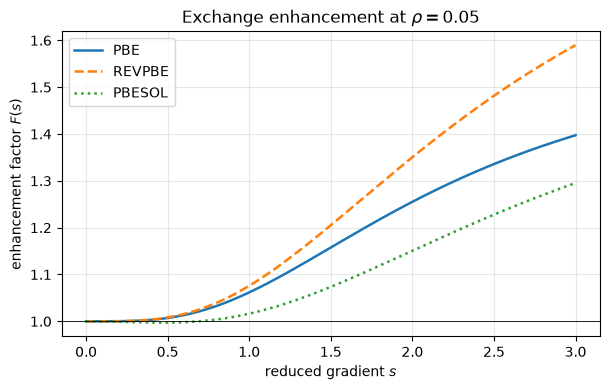

In [2]:
rho = 0.05
s = np.linspace(0.0, 3.0, 300)
kf = (3.0 * np.pi**2 * rho) ** (1.0 / 3.0)
sigma = (s * 2.0 * kf * rho) ** 2                 # |grad rho|^2 at each s, fixed rho

fig, ax = plt.subplots(figsize=(6.2, 4))
for name, style in (("PBE", "-"), ("REVPBE", "--"), ("PBESOL", ":")):
    f = get_functional(name)
    ex_gga = np.asarray(f.gradient_energy(jnp.full_like(sigma, rho), jnp.asarray(sigma)))
    ex_lda = float(rho * f.exchange(jnp.asarray(rho)))
    ax.plot(s, 1.0 + ex_gga / ex_lda, style, lw=1.8, label=name)
ax.axhline(1.0, color="k", lw=0.6)
ax.set_xlabel("reduced gradient $s$"); ax.set_ylabel("enhancement factor $F(s)$")
ax.set_title(r"Exchange enhancement at $\rho = %.2f$" % rho)
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()

## Only the energy is written down

QE's `XClib` carries hand-derived expressions for `v1` and `v2` beside each energy. Here
the energy is the only thing written down and both potentials are `jax.grad` of it — so
a new functional is an energy expression and a registration, with no algebra to get
wrong. The check is against QE's `pbex`, transcribed into this cell and nowhere else.

In [3]:
def qe_pbex(rho, grho, kappa=0.804, mu=0.2195149727645171):
    """`pbex` from XClib, in Hartree: the hand-derived potentials to reproduce."""
    c1, c2 = 0.75 / np.pi, 3.093667726280136
    agrho = np.sqrt(grho); kf = c2 * rho ** (1 / 3); dsg = 0.5 / kf
    s1 = agrho * dsg / rho; f2 = 1.0 + s1 * s1 * mu / kappa
    fx = kappa - kappa / f2; exunif = -c1 * kf
    dfx = 2.0 * mu * s1 / (f2 * f2)
    v1x = exunif * fx + exunif / 3.0 * fx + exunif * dfx * (-4.0 / 3.0 * s1)
    return exunif * fx * rho, v1x, exunif * dfx * dsg / agrho


E2 = 2.0                       # XClib returns Hartree; this code returns Rydberg
energy = get_functional("PBE").gradient_exchange
print("%6s %6s | %13s %13s | %13s %13s"
      % ("rho", "sigma", "v1 autodiff", "v1 QE", "v2 autodiff", "v2 QE"))
for r, sig in ((0.05, 0.01), (0.5, 0.3), (2.0, 5.0)):
    v1 = float(jax.grad(energy, argnums=0)(r, sig))
    v2 = 2.0 * float(jax.grad(energy, argnums=1)(r, sig))
    _, v1_qe, v2_qe = qe_pbex(r, sig)
    print("%6.2f %6.2f | %13.9f %13.9f | %13.9f %13.9f"
          % (r, sig, v1, E2 * v1_qe, v2, E2 * v2_qe))

   rho  sigma |   v1 autodiff         v1 QE |   v2 autodiff         v2 QE
  0.05   0.01 |   0.066124366   0.066124366 |  -0.627914775  -0.627914775
  0.50   0.30 |   0.016393593   0.016393593 |  -0.041548429  -0.041548429
  2.00   5.00 |   0.011017096   0.011017096 |  -0.006647590  -0.006647590


The second potential enters as $-\nabla\cdot(v_2\nabla\rho)$, a divergence taken on the
FFT grid, which integrates to zero over the cell and so moves no charge — it only moves
it around. On a PAW sphere the same term is a radial derivative plus an angular one, the
quadrature grows by two multipoles, and the $\theta$ component is divided by
$\sin\theta$ before projection.

## Against Quantum ESPRESSO

Three pseudopotential kinds under PBE, then three functionals on the same
norm-conserving cell.

In [4]:
import warnings

print("%-16s %18s %18s %14s" % ("case", "pypresso (Ry)", "QE (Ry)", "difference"))
for case in ("si2-nc-pbe", "si2-us-pbe", "si2-paw-pbe"):
    system, pseudos = load(case)
    result = run_scf(system, pseudos, conv_thr=1e-10, max_iterations=80)
    ref = reference(case)
    print("%-16s %18.9f %18.9f %14.2e"
          % (case, result.total_energy, ref.total_energy,
             result.total_energy - ref.total_energy))
    if case == "si2-nc-pbe":
        pbe_scf, pbe_pseudos = result, pseudos

print()
for case, label in (("si2-nc-pbe", "PBE"), ("si2-nc-revpbe", "revPBE"),
                    ("si2-nc-pbesol", "PBEsol")):
    system, pseudos = load(case)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")     # input_dft overriding the dataset, on purpose
        result = run_scf(system, pseudos, conv_thr=1e-10, max_iterations=80)
    ref = reference(case)
    print("%-16s %18.9f %18.9f %14.2e"
          % (label, result.total_energy, ref.total_energy,
             result.total_energy - ref.total_energy))

case                  pypresso (Ry)            QE (Ry)     difference


si2-nc-pbe            -15.727897810      -15.727897810       2.72e-10


si2-us-pbe            -22.822566057      -22.822566060       2.72e-09


si2-paw-pbe           -93.439615230      -93.439615230      -1.11e-10



PBE                   -15.727897810      -15.727897810       2.72e-10


revPBE                -15.734397095      -15.734397090      -4.59e-09


PBEsol                -15.696395527      -15.696395530       3.40e-09


## The bands, and what a gradient correction does not fix

PBE moves silicon's bands by tens of meV against LDA and its gap by about 0.1 eV — still
half of experiment's 1.17 eV. The band gap of a Kohn-Sham calculation is not the thing
experiment measures, and no gradient correction repairs that; what PBE does repair is the
energetics, which is why it is what structures and forces are computed with.

largest eigenvalue difference from QE: 0.052 meV
PBE gap: 0.565 eV   (experiment 1.17 eV)


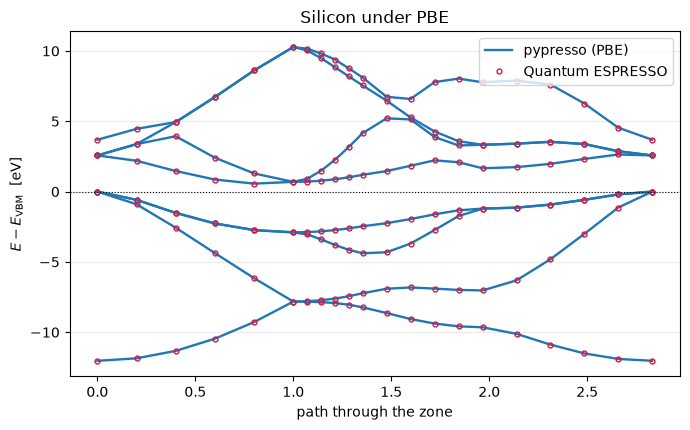

In [5]:
band_system = build_system(read_pw_input(CASES / "si2-nc-pbe-bands.in"))
bands = run_bands(band_system, pbe_pseudos, pbe_scf.density)
theirs = reference("si2-nc-pbe-bands").eigenvalues[0]
ours = bands.eigenvalues_ev
homo = ours[:, 3].max()

fig, ax = plt.subplots(figsize=(7, 4.4))
for band in range(ours.shape[1]):
    ax.plot(bands.path_length, ours[:, band] - homo, "-", color="C0", lw=1.7,
            label="pypresso (PBE)" if band == 0 else None)
    ax.plot(bands.path_length, theirs[:, band] - homo, "o", color="crimson", ms=3.5,
            mfc="none", label="Quantum ESPRESSO" if band == 0 else None)
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_ylabel(r"$E - E_{\rm VBM}$  [eV]"); ax.set_xlabel("path through the zone")
ax.set_title("Silicon under PBE"); ax.legend(loc="upper right")
ax.grid(alpha=0.25, axis="y"); fig.tight_layout()

print("largest eigenvalue difference from QE: %.3f meV"
      % (np.abs(ours - theirs).max() * 1e3))
print("PBE gap: %.3f eV   (experiment 1.17 eV)" % bands.gap(8))

---
**The detail:** `PLAN.md` §3 P13 — the four functional slots, `gradcorr` on the grid and
`PAW_gcxc_potential` on the spheres, and why only the energy is written down.
**The tests:** `tests/regression/test_gga.py`, `tests/unit/test_xc.py`.